# M8.3F — Representation ladder

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
**Not in Final Report** (report trains on anomaly only).

Compare **delta / clean / observed** on the frozen interpretive triad. Results: `checkpoints/m8/m08_3f_representation/`.


In [ ]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


In [ ]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache


In [ ]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import torch

from tomography_ml import get_device
from tomography_ml.gummybear_data_catalog.task_dataset import build_task_dataset
from tomography_ml.studies import M8_CANONICAL_LR_BY_ARCH
import tomography_ml_validation.milestone_08.validation as m8_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

from tomography_ml_validation.milestone_08 import DEFAULT_N_REPEAT

SMOKE = False
RUN_STUDY = None  # None = auto (run when runs CSV missing)
N_REPEAT = DEFAULT_N_REPEAT
BASE_SEED = 0
NUM_EPOCHS = 40 if SMOKE else 200
EARLY_STOP = 25 if SMOKE else 40

device = get_device()
print(f"device={device}")
print("canonical LRs", M8_CANONICAL_LR_BY_ARCH)


device=mps
canonical LRs {'pooled': 0.001, 'fourier': 0.03, 'flatten': 0.0003}


In [ ]:
from tomography_ml_validation.milestone_08 import (
    DEFAULT_N_REPEAT,
    load_m8_catalog_rows,
    load_win3f_results,
    plot_win3f_results,
    plot_win3f_results_by_architecture,
    run_win3f_representation_study,
    summarize_win3f,
    win3f_results_dir,
    win3_grids_summary,
)

results_dir = win3f_results_dir(ROOT)


## Milestone 8 Step 3F predefined grid

In [ ]:
display(win3_grids_summary()['3F_representation'])
run_installed_pytest_test(m8_validation, "test_m8_3f_selected_representation_is_delta")


,name,x_field,description
0,delta,anomaly_ref,particle_minus_clean (stored anomaly role)
1,clean,clean_ref,clean simulator camera image
2,observed,observed_ref,particle/dirty observed camera image


M8.3F
Test executed: test_m8_3f_selected_representation_is_delta()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_08/validation.py . [100%]
============================== 1 passed in 1.87s ===============================

Test proves: Milestone 8 Step 3F selected representation is delta / anomaly_ref.


## Train / validation study

In [ ]:
rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
summary_df, runs_df = load_win3f_results(ROOT)
should_run = RUN_STUDY if RUN_STUDY is not None else (runs_df is None or runs_df.empty)
if should_run:
    summary_df, runs_df, _ = run_win3f_representation_study(
        rows,
        device=device,
        num_epochs=NUM_EPOCHS,
        early_stop_patience=EARLY_STOP,
        results_dir=results_dir,
        n_repeat=N_REPEAT,
        base_seed=BASE_SEED,
    )
else:
    print("Loaded existing runs CSV — set RUN_STUDY=True to retrain.")
display(summary_df)


Loaded existing runs CSV — set RUN_STUDY=True to retrain.


,experiment_id,win,architecture_factor,hypothesis,variant,head_type,downsample,encoder_channels,architecture_config,parameter_count,...,x_field,train_RMSE_total_mean,train_RMSE_total_std,validation_RMSE_total_mean,validation_RMSE_total_std,best_validation_RMSE_total_mean,best_validation_RMSE_total_std,run_group,n_repeat,seeds
1,win3f__flatten_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,anomaly_ref,0.716433,0.112565,1.256095,0.025345,1.256095,0.025345,delta::flatten_base_mlp,5,"5,6,7,8,9"
0,win3f__fourier_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,anomaly_ref,0.806142,0.085891,1.269039,0.032558,1.269039,0.032558,delta::fourier_base_mlp,5,"5,6,7,8,9"
2,win3f__pooled_base_base,3F,input_representation,delta_oracle_vs_clean_vs_observed,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,anomaly_ref,1.450677,0.074117,1.849876,0.077828,1.849876,0.077828,delta::pooled_base_base,5,"5,6,7,8,9"
7,win3f__flatten_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,observed_ref,2.319452,0.148139,2.669813,0.106879,2.669813,0.106879,observed::flatten_base_mlp,5,"5,6,7,8,9"
6,win3f__fourier_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,observed_ref,2.590910,0.451074,2.933156,0.253870,2.933156,0.253870,observed::fourier_base_mlp,5,"5,6,7,8,9"
8,win3f__pooled_base_base,3F,input_representation,delta_oracle_vs_clean_vs_observed,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,observed_ref,5.226407,0.372620,4.911388,0.407093,4.911388,0.407093,observed::pooled_base_base,5,"5,6,7,8,9"
3,win3f__fourier_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,clean_ref,5.401213,0.017108,5.089514,0.004648,5.089514,0.004648,clean::fourier_base_mlp,5,"5,6,7,8,9"
4,win3f__flatten_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,clean_ref,5.398906,0.013736,5.090789,0.005271,5.090789,0.005271,clean::flatten_base_mlp,5,"5,6,7,8,9"
5,win3f__pooled_base_base,3F,input_representation,delta_oracle_vs_clean_vs_observed,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,clean_ref,5.392427,0.003903,5.093695,0.004188,5.093695,0.004188,clean::pooled_base_base,5,"5,6,7,8,9"


## Results

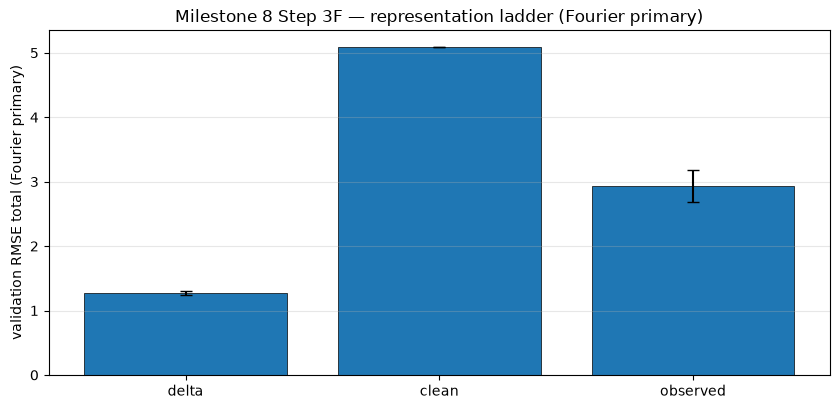

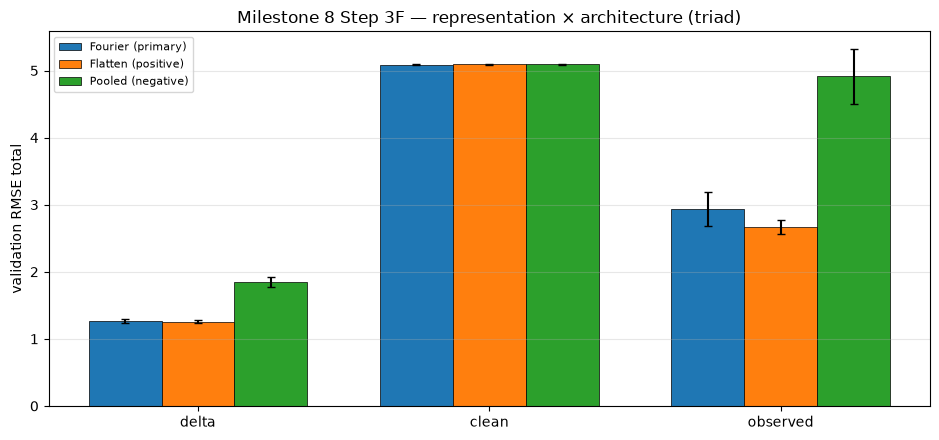

- delta: mean val RMSE 1.269.

- clean: mean val RMSE 5.090.

- observed: mean val RMSE 2.933.

- Freeze delta (`anomaly_ref`) at 3J; observed remains operational restoration target.

In [ ]:
fig_primary = plot_win3f_results(summary_df, runs_df=runs_df)
plt.show()

fig_grouped = plot_win3f_results_by_architecture(summary_df, runs_df=runs_df)
plt.show()

for line in summarize_win3f(summary_df):
    display(Markdown(f"- {line}"))


## Conclusions Milestone 08 Step 3f:

From this more "out-of-the-box" plot, it seems that the overlay from background signal poses a significant challenge to all the networks, further amplifying the difference between Fourier/Flatten on the one side and pooled on the other. For the purpose of experimental investigation of the Fourier architecture vs. other options, we use the clean delta for the remainder of the project as it provides the cleanest signal.